In [4]:
# load data and imports

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# load from saved csv rather than hitting api again
df = pd.read_csv("../data/raw_adoptions.csv")

print(df.shape)
df.head()

(173775, 12)


,animal_id,date_of_birth,datetime,monthyear,outcome_type,outcome_subtype,animal_type,sex_upon_outcome,age_upon_outcome,breed,color,name
0,A668305,2012-12-01,2013-12-02T00:00:00-05:00,12-2013,Transfer,Partner,Other,Unknown,1 year,Turtle Mix,Brown/Yellow,NaN
1,A673335,2012-02-22,2014-02-22T00:00:00-05:00,02-2014,Euthanasia,Suffering,Other,Unknown,2 years,Raccoon,Black/Gray,NaN
2,A675999,2013-04-03,2014-04-07T00:00:00-05:00,04-2014,Transfer,Partner,Other,Unknown,1 year,Turtle Mix,Green,NaN
3,A679066,2014-04-16,2014-05-16T00:00:00-05:00,05-2014,NaN,NaN,Other,Unknown,4 weeks,Rabbit Sh,Brown,NaN
4,A680855,2014-05-25,2014-06-10T00:00:00-05:00,06-2014,Transfer,Partner,Bird,Unknown,2 weeks,Duck,Yellow/Black,NaN


In [6]:
# check data types and missing values

#check data types of each column
print(df.dtypes)
print()

# check how many missing values are in each column
print(df.isnull().sum())

animal_id           object
date_of_birth       object
datetime            object
monthyear           object
outcome_type        object
outcome_subtype     object
animal_type         object
sex_upon_outcome    object
age_upon_outcome    object
breed               object
color               object
name                object
dtype: object

animal_id               0
date_of_birth           0
datetime                0
monthyear               0
outcome_type           46
outcome_subtype     94115
animal_type             0
sex_upon_outcome        1
age_upon_outcome        9
breed                   0
color                   0
name                49784
dtype: int64


In [ ]:
# every col is an obj
# date_of_birth and datetime should be dtm types

# outcome_subtype missing 54%, likely drop
# name missing 29%, do nameless pets have different outcomes? add binary has_name feature?
# outcome_type 46 missing, since this is target var, these rows need to be dropped
# age_upon_outcome 9 missing, trivial
# sex_upon_outcome 1 missing, trivial

In [9]:
# explore target var

# count each outcome type
print(df['outcome_type'].value_counts())
print()

# convert to % breakdown
print(df['outcome_type'].value_counts(normalize=True).round(3) * 100)

outcome_type
Adoption           84598
Transfer           48689
Return to Owner    25691
Euthanasia         10833
Died                1672
Rto-Adopt           1241
Disposal             877
Missing               92
Relocate              29
Stolen                 5
Lost                   2
Name: count, dtype: int64

outcome_type
Adoption           48.7
Transfer           28.0
Return to Owner    14.8
Euthanasia          6.2
Died                1.0
Rto-Adopt           0.7
Disposal            0.5
Missing             0.1
Relocate            0.0
Stolen              0.0
Lost                0.0
Name: proportion, dtype: float64


In [ ]:
# adoption rate 48.7%, well-balanced dataset for binary classification
# not adopted combined rate 51.3%
# transfer rate 28% and return to owner 14.8% are significant
# stolen, lost, relocate are trivial, group into "not adopted"
# rto-adopt rate 0.7% means pet was returned then adopted, group into "adopted"

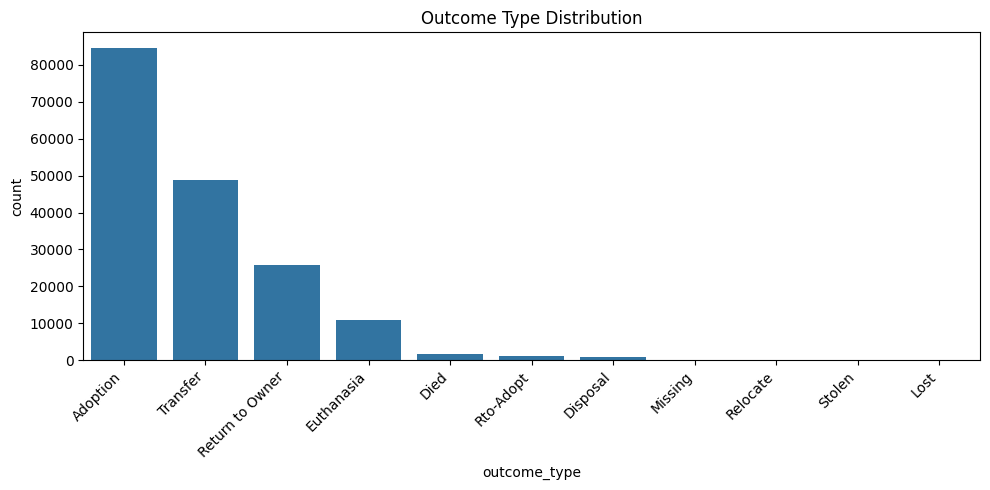

In [11]:
# visualize target var (bar chart)

plt.figure(figsize=(10, 5))
sns.countplot(data=df, x='outcome_type', order=df['outcome_type'].value_counts().index)
plt.title('Outcome Type Distribution')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

animal_type
Dog          94505
Cat          69399
Other         8960
Bird           877
Livestock       34
Name: count, dtype: int64

animal_type
Dog          54.4
Cat          39.9
Other         5.2
Bird          0.5
Livestock     0.0
Name: proportion, dtype: float64


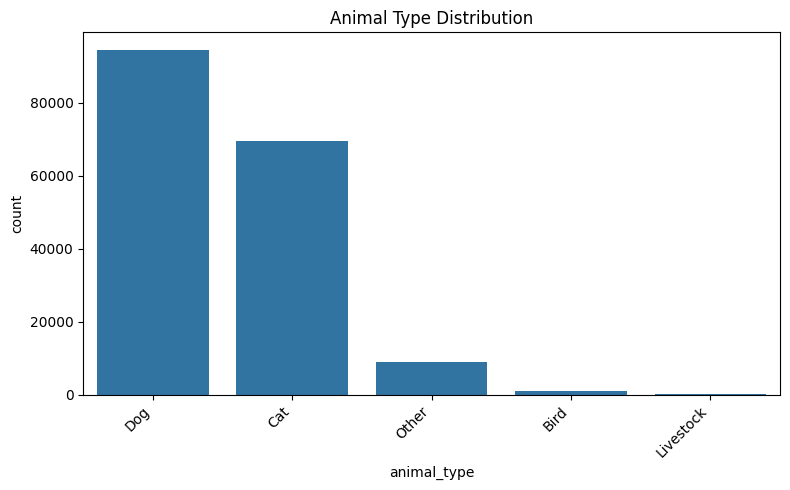

In [17]:
# explore pet types

# animal_type as value counts
print(df['animal_type'].value_counts())
print()

# convert to % breakdown
print(df['animal_type'].value_counts(normalize=True).round(3) * 100)

# animal_type as bar chart
plt.figure(figsize=(8, 5))
sns.countplot(data=df, x='animal_type', order=df['animal_type'].value_counts().index)
plt.title('Animal Type Distribution')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [18]:
# dogs and cats make up 94.3%
# other pet types (rabbits, guinea pigs, etc.) 5.2%
# birds and livestock are trivial, consider dropping

animal_type
Cat          51.6
Dog          50.2
Livestock    50.0
Bird         36.8
Other        11.2
Name: adopted, dtype: float64


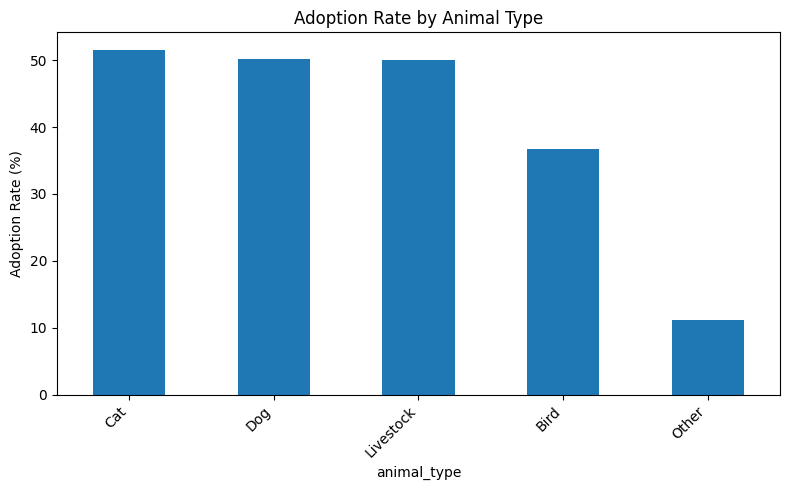

In [19]:
# explore adoption rate by animal type

# create a binary adopted column
df['adopted'] = (df['outcome_type'] == 'Adoption').astype(int)

# adoption rate % by animal type
adoption_by_type = df.groupby('animal_type')['adopted'].mean().sort_values(ascending=False).round(3) * 100
print(adoption_by_type)

# adoption by animal type as bar chart
plt.figure(figsize=(8, 5))
adoption_by_type.plot(kind='bar')
plt.title('Adoption Rate by Animal Type')
plt.ylabel('Adoption Rate (%)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [20]:
# cats and dogs have v similar adoption rates, can't use animal_type alone to differentiate
# livestock also at 50%, but w few records, this isn't statistically meaningful
# bird at 36.8%, noticeably lower
# other at 11.2%, dramatically lower, rabbits, guineas, and exotics are much harder to place; strong signal for model

sex_upon_outcome
Neutered Male    60933
Spayed Female    55269
Intact Male      22263
Intact Female    21804
Unknown          13505
Name: count, dtype: int64

sex_upon_outcome
Spayed Female    72.1
Neutered Male    67.1
Intact Female     8.6
Intact Male       7.5
Unknown           2.3
Name: adopted, dtype: float64


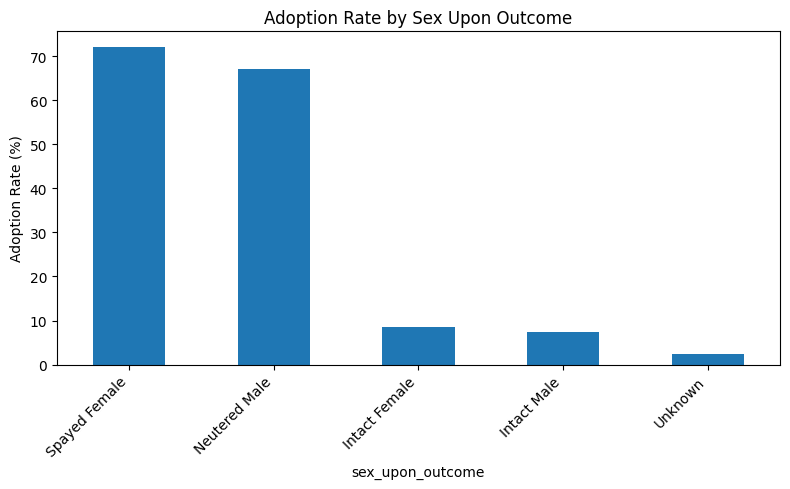

In [21]:
# explore adoption rate by sex

# value count for sex
print(df['sex_upon_outcome'].value_counts())
print()

# adoption rate % by sex
adoption_by_sex = df.groupby('sex_upon_outcome')['adopted'].mean().sort_values(ascending=False).round(3) * 100
print(adoption_by_sex)

# adoption by sex as bar chart
plt.figure(figsize=(8, 5))
adoption_by_sex.plot(kind='bar')
plt.title('Adoption Rate by Sex Upon Outcome')
plt.ylabel('Adoption Rate (%)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [ ]:
# sex_upon_outcome encodes sex AND fixed status
# fixed pets are significantly more likely to be adopted, 72% and 67% vs 8-9% for intact pets; big predictor for model
# intact pets are rarely adopted, most shelters fix, do intact pets leave via other routes?
# unknown status 2.3%, likely pets that came and went quickly or have incomplete records?

# features to consider: 
    # is_fixed (binary y/n)
    # sex (m/f/unknown)

has_name
0    27.1
1    57.4
Name: adopted, dtype: float64


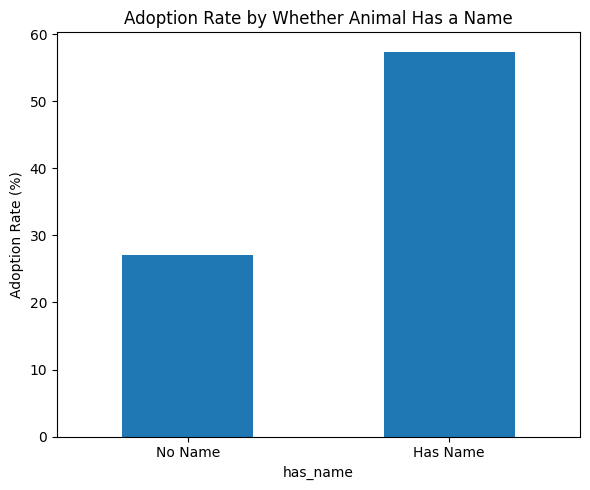

In [22]:
# explore adoption rate by name

# create a binary for if pet has name
df['has_name'] = df['name'].notna().astype(int)

# adoption rate % based on if pet has name
adoption_by_name = df.groupby('has_name')['adopted'].mean().round(3) * 100
print(adoption_by_name)

# adoption if named as bar chart
plt.figure(figsize=(6, 5))
adoption_by_name.plot(kind='bar')
plt.title('Adoption Rate by Whether Animal Has a Name')
plt.ylabel('Adoption Rate (%)')
plt.xticks([0, 1], ['No Name', 'Has Name'], rotation=0)
plt.tight_layout()
plt.show()

In [23]:
# named animals over 2x as likely to be adopted at 57.4% vs 27.1%
# has_name will be a strong feature for model

In [25]:
# strongest predictors based on eda

# animal_type: cats/dogs have 50%+ adoption rate vs other pets only 11%
# sex_upon_outcome: fixed pets have 67-72% adoption rate vs intact 7-9%
# has_name: named pets have 57% adoption rate vs unnamed 27%

In [31]:
# explore adoption rate by age

# convert age str to num value in days
def convert_age_to_days(age_str):
    
    # if  value is missing, return None rather than trying to convert it
    if pd.isna(age_str):
        return None
    
    # split str into two parts ("2", "years")
    parts = age_str.lower().split()
    if len(parts) < 2:
        return None
    
    # extract num and unit separately
    value = int(parts[0])
    unit = parts[1]
    
    # convert to days based on unit
    # 'in' catches singular and plural ("day" and "days")
    if 'day' in unit:
        return value
    elif 'week' in unit:
        return value * 7
    elif 'month' in unit:
        return value * 30
    elif 'year' in unit:
        return value * 365
    else:
        return None

# apply fn to every row in age col and store results in new col "age_in_days"
df['age_in_days'] = df['age_upon_outcome'].apply(convert_age_to_days)

# print new col to check that conversion worked
print(df['age_in_days'].describe())

count    173766.000000
mean        723.225591
std        1021.736466
min       -1460.000000
25%          60.000000
50%         365.000000
75%         730.000000
max       10950.000000
Name: age_in_days, dtype: float64


In [27]:
# negative min val -1460?
# dob recorded as after outcome date, likely a shelter error

In [28]:
# explore negative min age val

# count negative ages
print(df[df['age_in_days'] < 0]['age_in_days'].count())

# look at those records
print(df[df['age_in_days'] < 0][['animal_id', 'date_of_birth', 'datetime', 'age_upon_outcome', 'age_in_days']].head(10))

10
       animal_id date_of_birth             datetime age_upon_outcome  \
34320    A753893    2016-07-12  2015-07-02T11:06:00         -1 years   
52967    A725472    2020-04-29  2016-07-24T15:54:00         -3 years   
72341    A757376    2019-11-05  2017-09-05T19:25:00         -2 years   
85773    A725472    2020-04-29  2018-07-11T16:40:00         -1 years   
90880    A757376    2019-11-05  2018-10-21T19:01:00         -1 years   
91766    A783723    2023-02-07  2018-11-12T11:53:00         -4 years   
96190    A725472    2020-04-29  2019-02-26T14:34:00         -1 years   
103006   A797495    2020-12-16  2019-06-15T12:44:00         -1 years   
117704   A871020    2021-12-16  2020-03-17T12:04:00         -1 years   
172052   A922017    2028-05-01  2025-03-05T13:00:00         -3 years   

        age_in_days  
34320        -365.0  
52967       -1095.0  
72341        -730.0  
85773        -365.0  
90880        -365.0  
91766       -1460.0  
96190        -365.0  
103006       -365.0  
117704

In [29]:
# appears to be shelter entry issue, likely dob incorrect; not meaningful data
# only 10 entries, some of which appear multiple times (same pet, multiple outcomes over time); insignificant to total dataset
# treat these as missing ages, set to None

In [32]:
# update records with invalid negative age to have None val for age

# replace negative ages with None
df.loc[df['age_in_days'] < 0, 'age_in_days'] = None

# check that negative ages are gone
print(df[df['age_in_days'] < 0]['age_in_days'].count())
print(f"Remaining null ages: {df['age_in_days'].isna().sum()}")

0
Remaining null ages: 19


age_bucket
0-1mo     15.8
1-3mo     82.1
3-6mo     64.3
6-12mo    49.3
1-2yr     41.0
2-5yr     40.0
5-10yr    36.4
10yr+     25.4
Name: adopted, dtype: float64


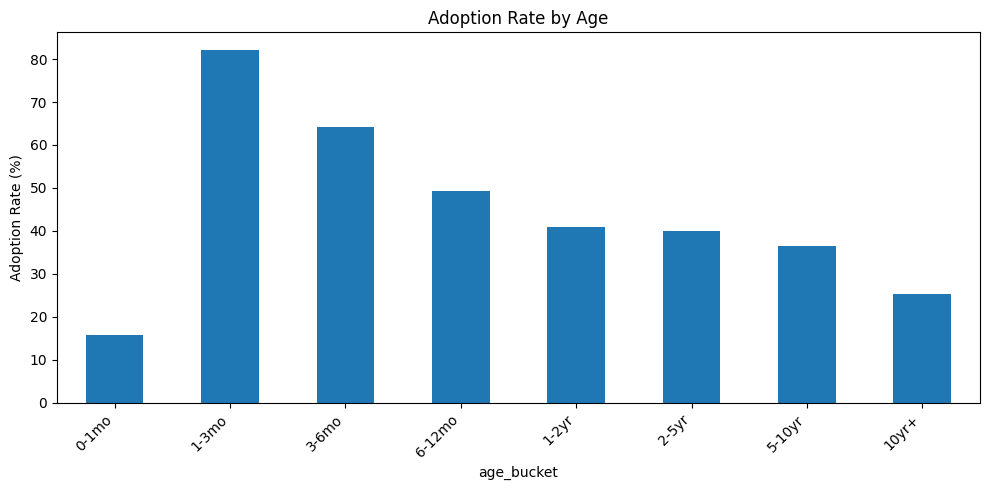

In [33]:
# explore how age relates to adoption

# create age buckets to make the analysis more readable
bins = [0, 30, 90, 180, 365, 730, 1825, 3650, float('inf')]
labels = ['0-1mo', '1-3mo', '3-6mo', '6-12mo', '1-2yr', '2-5yr', '5-10yr', '10yr+']

df['age_bucket'] = pd.cut(df['age_in_days'], bins=bins, labels=labels)

# adoption rate % by age bucket
adoption_by_age = df.groupby('age_bucket', observed=True)['adopted'].mean().round(3) * 100
print(adoption_by_age)

# adoption rate by age as bar chart
plt.figure(figsize=(10, 5))
adoption_by_age.plot(kind='bar')
plt.title('Adoption Rate by Age')
plt.ylabel('Adoption Rate (%)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [34]:
# 1-3 mo has highest rate at 82.1% adoption
# 0-1 mo is only 15.8%, too young for adoption, likely go to foster or transfer
# adoption rate declines with age; older animals are harder to place
# aside from prenatal (too young), senior dogs are the least adoptable at 25.4%
# age is a strong predictor for model

In [35]:
# strongest predictors based on eda

# animal_type: cats/dogs have 50%+ adoption rate vs other pets only 11%
# sex_upon_outcome: fixed pets have 67-72% adoption rate vs intact 7-9%
# has_name: named pets have 57% adoption rate vs unnamed 27%
# age_bucket: 1-3 mo have 82.1% adoption rate, declines steadily with age

In [36]:
# explore breeds

# print 20 breeds by count
print(df['breed'].value_counts().head(20))

breed
Domestic Shorthair Mix       34039
Domestic Shorthair           23842
Pit Bull Mix                 10151
Labrador Retriever Mix        8812
Chihuahua Shorthair Mix       6920
German Shepherd Mix           4053
Pit Bull                      3407
Domestic Medium Hair Mix      3377
Bat                           2356
Domestic Medium Hair          2103
Labrador Retriever            2029
Chihuahua Shorthair           2009
Australian Cattle Dog Mix     1991
German Shepherd               1826
Bat Mix                       1756
Domestic Longhair Mix         1687
Siamese Mix                   1475
Dachshund Mix                 1191
Boxer Mix                     1185
Border Collie Mix             1150
Name: count, dtype: int64


In [37]:
# domestic shorthair combined make up nearly 58000 records
# pitties make up over 10000 records, one of the most common and historically hardest to adopt out
# bats appear? likely wildlife rather than pet cases
# mix vs purebread; many breeds appear twice, consider is_mixed feature
# likely hundreds of unique breeds, too many to use directly for model

In [38]:
# explore unique breeds

print(f"Total unique breeds: {df['breed'].nunique()}")

# adoption rate for top 20 breeds
top_breeds = df['breed'].value_counts().head(20).index
adoption_by_breed = df[df['breed'].isin(top_breeds)].groupby('breed')['adopted'].mean().sort_values(ascending=False).round(3) * 100
print(adoption_by_breed)

Total unique breeds: 3010
breed
Domestic Medium Hair         62.2
Australian Cattle Dog Mix    58.7
German Shepherd              57.9
Border Collie Mix            57.7
Domestic Shorthair           57.7
German Shepherd Mix          56.6
Labrador Retriever Mix       55.7
Siamese Mix                  51.6
Labrador Retriever           51.3
Pit Bull                     51.1
Domestic Longhair Mix        50.7
Domestic Medium Hair Mix     49.8
Dachshund Mix                49.6
Boxer Mix                    49.4
Chihuahua Shorthair Mix      48.1
Chihuahua Shorthair          46.8
Domestic Shorthair Mix       46.3
Pit Bull Mix                 43.0
Bat                           0.0
Bat Mix                       0.0
Name: adopted, dtype: float64


In [ ]:
# over 3000 unique breeds is too many to use; consider how to handle this in feature eng
# adoption rates are relatively close across the board at 43-62%, not as dramatic as age or sex
# pitty mix at 43% and pitty at 51% indicates "mix" label carries some bias
# bats at 0% makes sense, they are wildlife and not adoptable pets; filter or separate wildlife?
# is_mix would be a useful feature; explore gap bt mixes and purebreds
    # is_mix as binary?
    # group broader categories (cat, s dog, l dog, wildlife, etc)?
    # use only top N breeds 